# Honeycutt Algorithm

R. Kent Honeycutt, "CCD Ensemble Photometry on an Inhomogeneous Set of Exposures", Publications of the Astronomical Society of the Pacific, 104: 435-440, 1992 June

- choose one aperture size

Honeycutt:
- assuming each exposure has a magnitude offset em(e) (representing whole-frame variations due to extinciton etc)
- assuming each source as an average instrumental magnitude mo(s) in absense of transparency variations
- use least squares to solve for the m0, em, given measured magnitudes of each source in each exposure

In [39]:
import os
# trying to fix kernel crash issue
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table, join

### Load the tables

Point `reduce_dir` at a folder written by `pw-aperture` (i.e. containing `sources.*`,
`images.*`, `flux.*`).

In [40]:
#reduce_dir = Path("/home/adamarthurryan/Desktop/baron obs/pandora/pandorahatp11multibandseries_20260701_baron_gp/pw-reduce")
reduce_dir = Path("/home/adamarthurryan/Desktop/baron obs/mkr421/mrk421microvariabilityirg_20260708_baron_ip/pw-reduce")
#reduce_dir = Path("/home/adamarthurryan/Desktop/baron obs/pandora/pandoraWASP80_20260620_baron_ip/pw-reduce/")
gaia_filter_key = "i_sdss_mag"
target_name = "Mrk 421"

source_table = Table.read(next(reduce_dir.glob("sources.*")))
image_table = Table.read(next(reduce_dir.glob("images.*")))
flux_table = Table.read(next(reduce_dir.glob("flux.*")))


len(source_table), len(image_table), len(flux_table)

(29, 29, 841)

#### Pick an aperture

for now, just pick a single aperture 

In [41]:
aperture_index = 20
flux_1ap = flux_table.copy()

flux_1ap["src_flux"] = flux_table["src_flux"][:, aperture_index]
flux_1ap["src_flux_error"] = flux_table["src_flux_error"][:, aperture_index]
flux_1ap["bkg_flux"] = flux_table["bkg_flux"][:, aperture_index]



#### Honeycut Algorithm


In [ ]:
from photometry_workflow.common.error import magnitude_error

# number of exposures (images) and sources 
ee = len(image_table)
ss = len(source_table)

# pivot to a pandas df
df = flux_1ap.to_pandas()
src_flux = df.pivot(index='image_id', columns='source_id', values='src_flux').to_numpy()
src_flux_error = df.pivot(index='image_id', columns='source_id', values='src_flux_error').to_numpy()

# weights of each source in each expoure
# use inverse of square magnitude error
#w = np.ones(src_flux.shape) 
w = 1 / magnitude_error(src_flux,src_flux_error)**2

#test: zero out weights of target star
w[:, 18] = w[:, 18]*0

#test zero out a poorly behaved star
w[:, 3] = w[:, 3]*0

# measured instrumental magnitudes
m = -2.5 * np.log10(src_flux)

# p = [em(1), ..., em(ee), m0(1), ..., m0(ss)]
# Y = [sum_s(w(1,s)*m(1,s)), ..., sum_s(w(ee,s)*m(ee,s)), sum_e(w(e,1)*m(e,1)), ..., sum_e(w(e,ss)*m(e,ss))]

# set up the matrices
wm = w * m
Y = np.concatenate([wm.sum(axis=1), wm.sum(axis=0)])

Xul = np.diag(w.sum(axis=1))
Xlr = np.diag(w.sum(axis=0))
Xur = w
Xll = w.T

Xu = np.column_stack([Xul, Xur])
Xl = np.column_stack([Xll, Xlr])
X = np.vstack([Xu, Xl])

p, *_ = np.linalg.lstsq(X,Y, rcond=None)
#np.linalg.inv(X.T @ X) @ X.T @ Y

em = p[:ee]
m0 = p[-ss:]

M = m-em[ :,None]

### Find the target star and plot the results

Target index is 18
<SkyCoord (ICRS): (ra, dec) in deg
    (166.11378085, 38.20893663)>


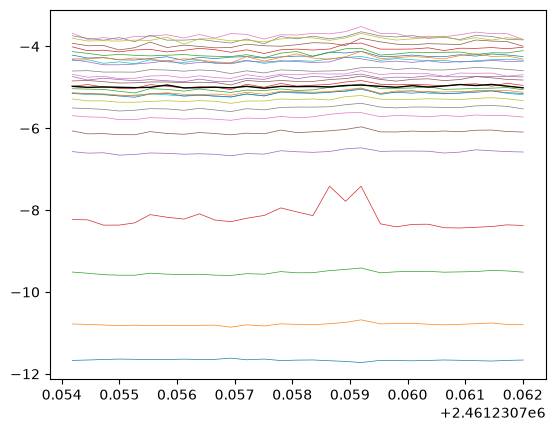

In [56]:
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


# get target position
mast = Mast()
target_coord = mast.resolve_object(target_name)

# make catalog from sources
source_coord = SkyCoord(ra=source_table["centroid_ra"], dec=source_table["centroid_dec"], frame="icrs")

target_index = int(target_coord.match_to_catalog_sky(source_coord)[0])

print(f"Target index is {target_index}")
print(f"{source_coord[target_index]}")

import matplotlib.pyplot as plt
plt.plot(image_table['time'], M, lw=0.5)
plt.plot(image_table['time'], M[:, target_index], lw=1, color="black")
plt.show()

In [53]:
print(source_table)

source_id     centroid_x     ... f814w_acswfc_mag f814w_acswfc_flag
                             ...       mag                         
--------- ------------------ ... ---------------- -----------------
        0   2591.61407579273 ...         5.818088                 0
        1 2601.0150684931505 ...        6.9589686                 0
        2 2642.8862559241707 ...               --                --
        3 2062.8743842364534 ...         9.223349                 0
        4 1033.1400966183576 ...        11.193426                 1
        5  1245.374193548387 ...        11.686234                 1
        6 495.06299212598424 ...        12.060693                 1
        7  238.1081081081081 ...        12.198474                 1
        8 2259.7395833333335 ...        12.418364                 1
      ...                ... ...              ...               ...
       19             1604.5 ...        13.429286                 1
       20  3145.560975609756 ...        13.52018